In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Freeze settings I trained
freeze_values = [23, 21, 19, 17, 15, 13, 11]

#NOTE BTW I FOLLOWED THIS NAMING/PATH SCHEME FOR ALL MY MODELS:
# MDP-stryker-cv/runs/detect/runs/detect/freezeX/weights/best.pt
# Where X is the number of layers I froze for that model

# Base paths
BASE = Path("MDP-stryker-cv")
DATA_YAML = BASE / "d1d2_stratified" / "data.yaml"

# Files to produce
wanted_plots = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]

summary_rows = []

for freeze in freeze_values:
    weights_path = BASE / "runs" / "detect" / "runs" / "detect" / f"freeze{freeze}" / "weights" / "best.pt"
    
    if not weights_path.exists():
        print(f"Skipping freeze={freeze}: missing weights at {weights_path}")
        continue

    print(f"\n=== Validating freeze={freeze} ===")
    model = YOLO(str(weights_path))

    # Run validation on the test split
    # split='test' tells Ultralytics to use the test section from data.yaml
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        plots=True,
        save_json=False,
        project=str(BASE / "runs" / "test_eval"),
        name=f"freeze{freeze}",
        exist_ok=True,
        verbose=True,
    )

    # Standard detection metrics
    precision = float(metrics.box.mp)       # mean precision
    recall = float(metrics.box.mr)          # mean recall
    map50 = float(metrics.box.map50)        # mAP@0.5
    map50_95 = float(metrics.box.map)       # mAP@0.5:0.95

    # Custom detection "accuracy" from confusion matrix:
    # accuracy = TP / (TP + FP + FN)
    # Ultralytics confusion matrix is usually (nc+1, nc+1) including background
    det_accuracy = None
    try:
        cm = metrics.confusion_matrix.matrix
        # cm shape is usually [num_classes+1, num_classes+1]
        # last row/col are background-related FP/FN accounting
        n = cm.shape[0] - 1

        tp = cm[:n, :n].diagonal().sum()
        fp = cm[:n, n].sum()        # predicted class when GT is background
        fn = cm[n, :n].sum()        # GT class predicted as background

        denom = tp + fp + fn
        det_accuracy = float(tp / denom) if denom > 0 else 0.0
    except Exception as e:
        print(f"Could not compute custom accuracy for freeze={freeze}: {e}")

    save_dir = Path(metrics.save_dir)

    # Check which requested plot files were created
    plot_status = {}
    for plot_name in wanted_plots:
        plot_path = save_dir / plot_name
        plot_status[plot_name] = plot_path.exists()

    row = {
        "freeze_layers": freeze,
        "weights_path": str(weights_path),
        "eval_dir": str(save_dir),
        "precision": precision,
        "recall": recall,
        "mAP50": map50,
        "mAP50-95": map50_95,
        "detection_accuracy": det_accuracy,
    }
    row.update({f"has_{name}": exists for name, exists in plot_status.items()})
    summary_rows.append(row)

results_df = pd.DataFrame(summary_rows).sort_values("freeze_layers", ascending=False).reset_index(drop=True)
results_df


=== Validating freeze=23 ===
Ultralytics 8.4.21 🚀 Python-3.9.7 torch-2.8.0+cu128 CUDA:0 (Tesla V100-PCIE-16GB, 16144MiB)
YOLO26s summary (fused): 122 layers, 9,467,502 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.9±2.5 MB/s, size: 7.2 KB)
val: Scanning /home/kayleyg/MDP-stryker-cv/d1d2_stratified/test/labels... 1918 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1918/1918 895.2it/s 2.1s0.0s
val: New cache created: /home/kayleyg/MDP-stryker-cv/d1d2_stratified/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 120/120 10.1it/s 11.8s0.1s
                   all       1918       1977      0.864      0.862      0.914      0.739
              scissors        741        768      0.906      0.928      0.964      0.817
               forceps        686        718      0.919       0.93      0.965      0.835
             bp_handle        182        182      0.964          1 

,freeze_layers,weights_path,eval_dir,precision,recall,mAP50,mAP50-95,detection_accuracy,has_BoxPR_curve.png,has_BoxF1_curve.png,has_BoxP_curve.png,has_BoxR_curve.png,has_confusion_matrix.png,has_confusion_matrix_normalized.png
0,23,MDP-stryker-cv/runs/detect/runs/detect/freeze2...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.864448,0.862455,0.913597,0.739403,0.834317,True,True,True,True,True,True
1,21,MDP-stryker-cv/runs/detect/runs/detect/freeze2...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.936886,0.930013,0.954745,0.816296,0.913002,True,True,True,True,True,True
2,19,MDP-stryker-cv/runs/detect/runs/detect/freeze1...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.929349,0.956292,0.956644,0.820012,0.909434,True,True,True,True,True,True
3,17,MDP-stryker-cv/runs/detect/runs/detect/freeze1...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.948993,0.937705,0.956494,0.822213,0.918816,True,True,True,True,True,True
4,15,MDP-stryker-cv/runs/detect/runs/detect/freeze1...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.942557,0.939853,0.959048,0.830189,0.918610,True,True,True,True,True,True
5,13,MDP-stryker-cv/runs/detect/runs/detect/freeze1...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.921436,0.940662,0.950741,0.825420,0.930053,True,True,True,True,True,True
6,11,MDP-stryker-cv/runs/detect/runs/detect/freeze1...,/home/kayleyg/runs/detect/MDP-stryker-cv/runs/...,0.921436,0.940662,0.950741,0.825420,0.930053,True,True,True,True,True,True


In [6]:
%matplotlib inline

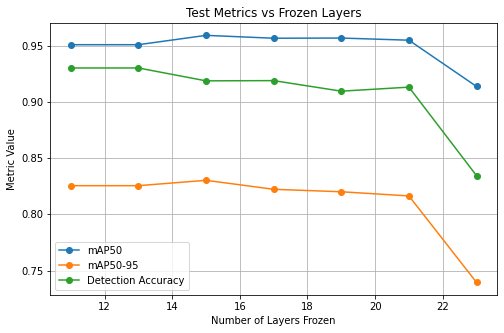

In [7]:
import matplotlib.pyplot as plt

plot_df = results_df.sort_values("freeze_layers")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["freeze_layers"], plot_df["mAP50"], marker="o", label="mAP50")
plt.plot(plot_df["freeze_layers"], plot_df["mAP50-95"], marker="o", label="mAP50-95")
plt.plot(plot_df["freeze_layers"], plot_df["detection_accuracy"], marker="o", label="Detection Accuracy")
plt.xlabel("Number of Layers Frozen")
plt.ylabel("Metric Value")
plt.title("Test Metrics vs Frozen Layers")
plt.legend()
plt.grid(True)
plt.show()

,freeze_layers,avg_time_per_epoch,total_time,num_epochs,results_csv
6,11,253.798,12689.90,50,MDP-stryker-cv/runs/detect/runs/detect/freeze1...
5,13,254.660,12733.00,50,MDP-stryker-cv/runs/detect/runs/detect/freeze1...
4,15,241.058,12052.90,50,MDP-stryker-cv/runs/detect/runs/detect/freeze1...
3,17,222.274,11113.70,50,MDP-stryker-cv/runs/detect/runs/detect/freeze1...
2,19,224.746,11237.30,50,MDP-stryker-cv/runs/detect/runs/detect/freeze1...
1,21,207.242,10362.10,50,MDP-stryker-cv/runs/detect/runs/detect/freeze2...
0,23,197.727,9886.35,50,MDP-stryker-cv/runs/detect/runs/detect/freeze2...


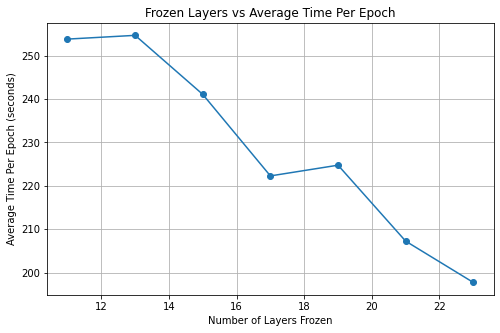

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

freeze_values = [23, 21, 19, 17, 15, 13, 11]
BASE = Path("MDP-stryker-cv")

time_rows = []

for freeze in freeze_values:
    csv_path = BASE / "runs" / "detect" / "runs" / "detect" / f"freeze{freeze}" / "results.csv"

    if not csv_path.exists():
        print(f"Skipping freeze={freeze}: missing CSV at {csv_path}")
        continue

    df = pd.read_csv(csv_path)

    if "time" not in df.columns:
        print(f"Skipping freeze={freeze}: no 'time' column found")
        continue

    # make sure sorted by epoch
    df = df.sort_values("epoch").reset_index(drop=True)

    # cumulative total time -> per-epoch time
    per_epoch_time = df["time"].diff()

    # first epoch time is just the first cumulative entry
    per_epoch_time.iloc[0] = df.loc[0, "time"]

    avg_time = per_epoch_time.mean()

    time_rows.append({
        "freeze_layers": freeze,
        "avg_time_per_epoch": avg_time,
        "total_time": df["time"].iloc[-1],
        "num_epochs": len(df),
        "results_csv": str(csv_path),
    })

time_df = pd.DataFrame(time_rows).sort_values("freeze_layers")
display(time_df)

plt.figure(figsize=(8, 5))
plt.plot(time_df["freeze_layers"], time_df["avg_time_per_epoch"], marker="o")
plt.xlabel("Number of Layers Frozen")
plt.ylabel("Average Time Per Epoch (seconds)")
plt.title("Frozen Layers vs Average Time Per Epoch")
plt.grid(True)
plt.show()

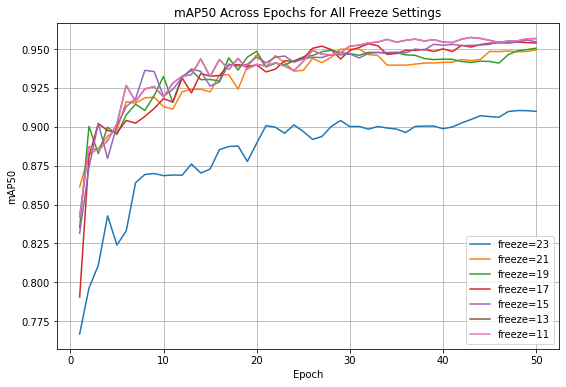

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

freeze_values = [23, 21, 19, 17, 15, 13, 11]
BASE = Path("MDP-stryker-cv")

plt.figure(figsize=(9, 6))

for freeze in freeze_values:
    csv_path = BASE / "runs" / "detect" / "runs" / "detect" / f"freeze{freeze}" / "results.csv"

    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path).sort_values("epoch")
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label=f"freeze={freeze}")

plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.title("mAP50 Across Epochs for All Freeze Settings")
plt.grid(True)
plt.legend()
plt.show()

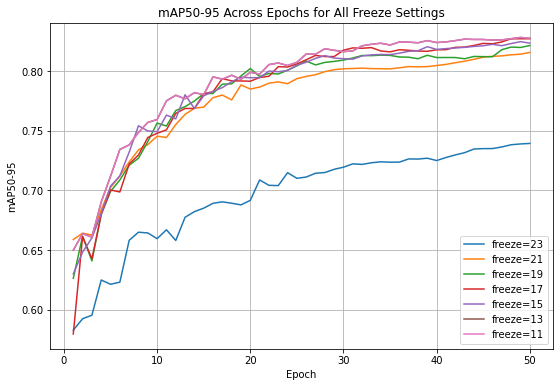

In [3]:
plt.figure(figsize=(9, 6))

for freeze in freeze_values:
    csv_path = BASE / "runs" / "detect" / "runs" / "detect" / f"freeze{freeze}" / "results.csv"

    if not csv_path.exists():
        continue

    df = pd.read_csv(csv_path).sort_values("epoch")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label=f"freeze={freeze}")

plt.xlabel("Epoch")
plt.ylabel("mAP50-95")
plt.title("mAP50-95 Across Epochs for All Freeze Settings")
plt.grid(True)
plt.legend()
plt.show()